## Homework B03: Bangladesh Data: Effect of Surviving Children in Bangladesh (Numpyro Version)
By Prabhakar Srivastava

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import jax.numpy as jnp
from jax.random import split, PRNGKey
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive
import arviz as az
from graphviz import Digraph as gr
from jax.scipy.special import expit

Random Seed and plotting style

In [2]:
random_seed = sum(map(ord, "Homework 3 Numpyro Version"))

az.style.use("arviz-doc")

numpyro.set_host_device_count(4)
numpyro.enable_x64()

DAG for Problem

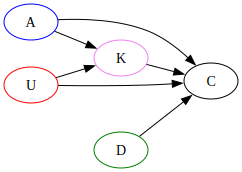

In [3]:
g = gr()
g.attr(rankdir="LR")
g.node(label="A", name="A", color="blue")
g.node(label="K", name="K", color="violet")
g.node(label="C", name="C", color="black")
g.node(label="U", name="U", color="red")
g.node(label="D", name="D", color="green")
g.edge(tail_name="A", head_name="K")
g.edge(tail_name="A", head_name="C")
g.edge(tail_name="K", head_name="C")
g.edge(tail_name="U", head_name="C")
g.edge(tail_name="U", head_name="K")
g.edge(tail_name="D", head_name="C")
g

Wish to find effect of $K \rightarrow C$ <br>
Non-Causal Path: $K \leftarrow A \rightarrow C$: Condition on $A$ <br>
Non-Causal Path: $K \leftarrow U \rightarrow C$: Condition on $U$ <br>
Condition on $D$ to include district level confounds

Import the data

In [4]:
# Data
filepath_str:str = "https://raw.githubusercontent.com/rmcelreath/rethinking/master/data/bangladesh.csv"
df = pd.read_csv(filepath_str, sep=";")

# Adjust district_id and living.children so that it begins at 0 instead of 1
df["district_id"] = df["district"].sub(1)
df["K"] = df["living.children"].sub(1)

NDistricts = df["district"].max()
NK = df["living.children"].max()

df.head()

,woman,district,use.contraception,living.children,age.centered,urban,district_id,K
0,1,1,0,4,18.4400,1,0,3
1,2,1,0,1,-5.5599,1,0,0
2,3,1,0,3,1.4400,1,0,2
3,4,1,0,4,8.4400,1,0,3
4,5,1,0,1,-13.5590,1,0,0


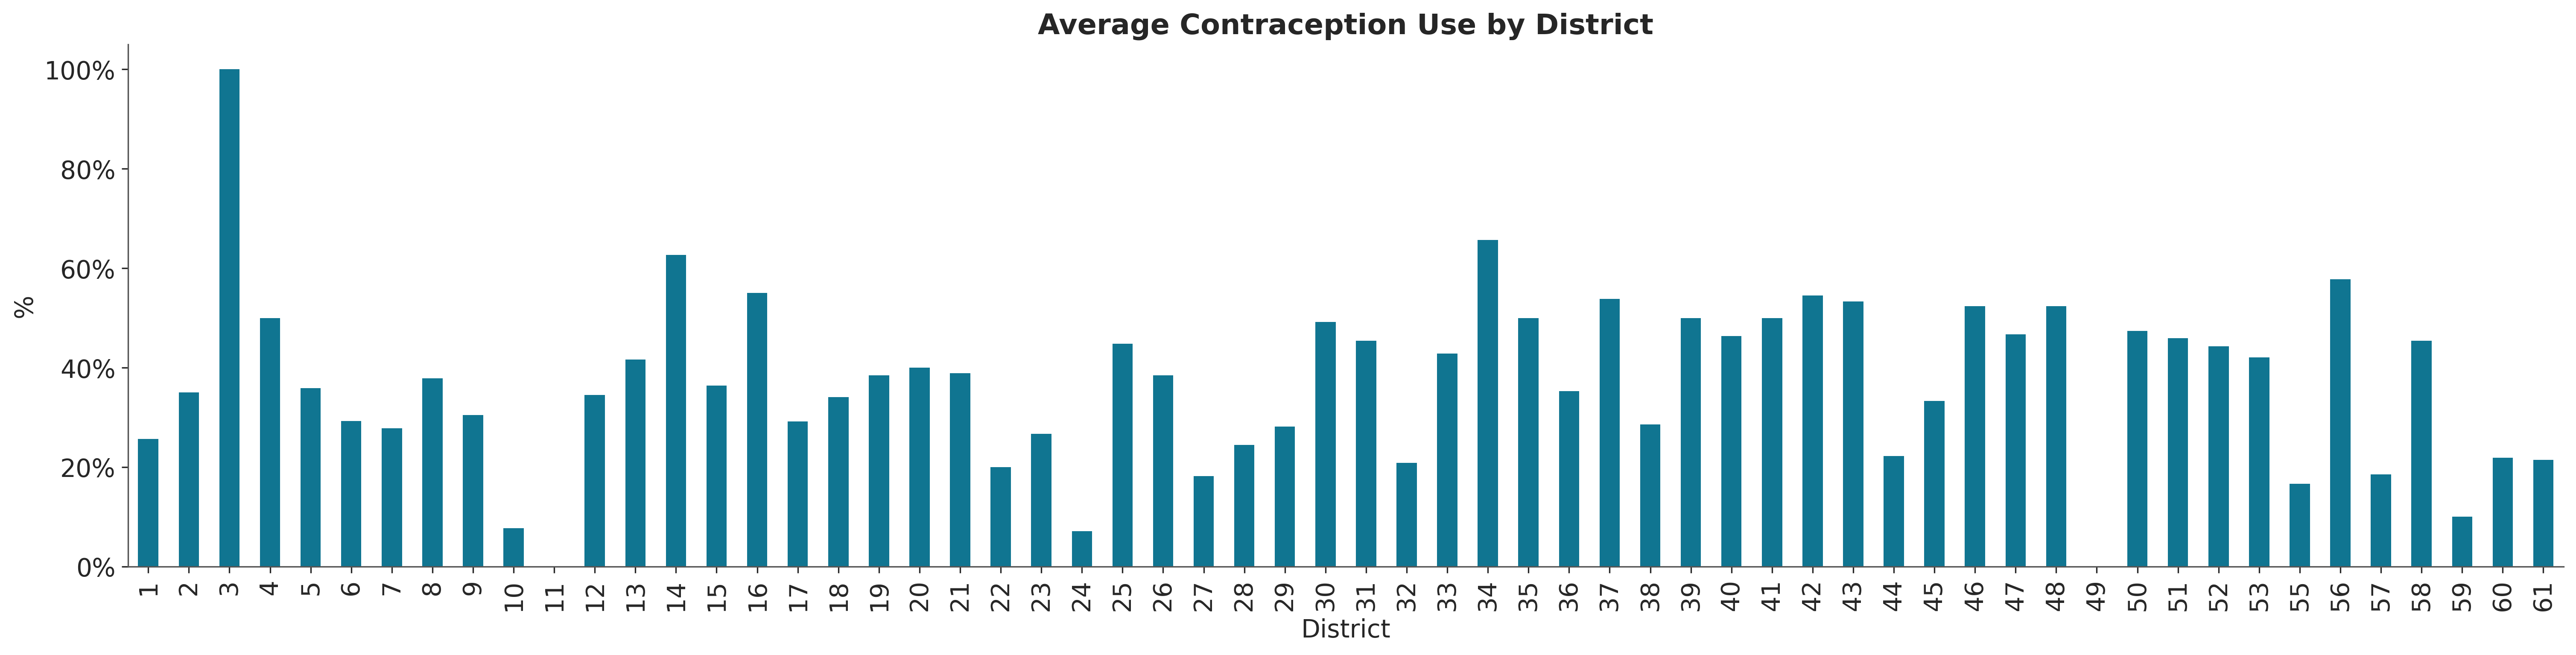

In [5]:
# Plot Contraception use by district
fig, ax = plt.subplots(figsize=(20., 5.))
summary_df = (
    df
    .groupby("district")
    .agg({"use.contraception": "mean",
          "K": "count"
         })
    .rename(
        columns = 
        {"use.contraception": "Contraception Use",
         "K": "#"
        }
    )
    .sort_index(ascending=True)
    .reset_index()
)
summary_df.plot(x="district", y="Contraception Use", ax=ax, kind="bar")
ax.get_legend().remove()
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel("District"); ax.set_ylabel("%"); ax.set_title("Average Contraception Use by District")
plt.show()

Begin Model in Numpyro

In [6]:
def hm_b03(A:jnp.array = jnp.array(df["age.centered"].values),
           D:jnp.array = jnp.array(df["district_id"].values).astype(jnp.int32),
           U:jnp.array = jnp.array(df["urban"].values),
           K:jnp.array = jnp.array(df["K"].values).astype(jnp.int32),
           C:jnp.array = jnp.array(df["use.contraception"].values),
           n_effects:int = 3 # 
          ) -> None:
    '''
    Estimate the causal effect of K (kids) on contraception use.
    There will be effects of correlated district level confounds.
    Uses a non-centered parameterization
    It will be a big model.
    '''

    # Prior on age: Will not vary by district
    βA = numpyro.sample("βA", dist.Normal(loc=0., scale=0.5))

    # Tackle the ordered effect: We model kids as an ordered effect
    δ_ = numpyro.sample("δ_", dist.Dirichlet(jnp.ones(NK - 1)))
    δ = jnp.concatenate([jnp.array([0.]), jnp.cumsum(δ_)]) # Always confuses me so have to think through it :)

    # Correlated Effects: intercept, U, and K
    σ = numpyro.sample("σ", dist.Exponential(1.0).expand([n_effects]))
    L_ = numpyro.sample("L", dist.LKJCholesky(n_effects, concentration=2.0)) # Prior on the correlation matrix
    L = jnp.diag(σ) @ L_ # Covariance matrix: with dimensions of (n_effects, n_effects)

    # Create a Normal random variable with dimensions (n_effects, n_groups)
    #with numpyro.plate("n_groups", NDistricts, dim=-2): # Outer dim
    #    with numpyro.plate("n_effects", n_effects, dim=-1): # Inner dim
    #        Z = numpyro.sample("Z", dist.Normal(loc=0., scale=1.))

    
    Z = numpyro.sample("Z", dist.Normal(loc=0., scale=1.).expand([n_effects, NDistricts]))

    # Want resulting to have dimensions (n_groups, n_effects)
    correlated_vec = (L @ Z).T

    # Extract the correlated parameters
    α_bar = numpyro.sample("α_bar", dist.Normal(0, 2))
    βU_bar = numpyro.sample("βU_bar", dist.Normal(0, 1))
    βK_bar = numpyro.sample("βK_bar", dist.Normal(0, 1))
    
    α = α_bar + correlated_vec[:, 0]
    βU = βU_bar + correlated_vec[:, 1]
    βK = βK_bar + correlated_vec[:, 2]

    # Linear regression component: prelude to GLM
    μ = α[D] + βA * A + βU[D] * U + βK[D] * δ[K] # α, βU, and βK are correlated
    p = numpyro.deterministic("p", expit(μ))

    # Likelihood
    with numpyro.plate("obs", len(A)):
        likelihood = numpyro.sample("likelihood", dist.Bernoulli(p), obs=C)

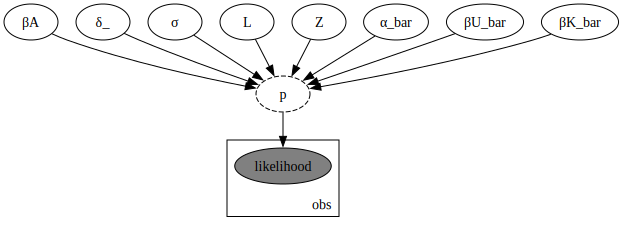

In [7]:
numpyro.render_model(hm_b03)

In [8]:
rng_key = PRNGKey(random_seed)
rng_key, rng_subkey = split(rng_key)

mcmc = MCMC(NUTS(hm_b03, target_accept_prob=0.95), num_chains=4, num_warmup=1_000, num_samples=2_000)
mcmc.run(rng_subkey)

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

In [9]:
mcmc.print_summary()


                mean       std    median      5.0%     95.0%     n_eff     r_hat
    L[0,0]      1.00      0.00      1.00      1.00      1.00       nan       nan
    L[0,1]      0.00      0.00      0.00      0.00      0.00       nan       nan
    L[0,2]      0.00      0.00      0.00      0.00      0.00       nan       nan
    L[1,0]     -0.67      0.18     -0.70     -0.93     -0.42   2114.99      1.00
    L[1,1]      0.70      0.15      0.71      0.47      0.96   2406.79      1.00
    L[1,2]      0.00      0.00      0.00      0.00      0.00       nan       nan
    L[2,0]     -0.39      0.35     -0.47     -0.89      0.14   1607.27      1.00
    L[2,1]      0.00      0.32     -0.01     -0.52      0.54   2532.86      1.00
    L[2,2]      0.78      0.15      0.80      0.57      1.00   3698.52      1.00
    Z[0,0]     -1.24      0.65     -1.22     -2.33     -0.20   3668.29      1.00
    Z[0,1]     -0.19      0.74     -0.18     -1.41      1.02   9033.71      1.00
    Z[0,2]      0.08      1

Create some predictions

In [10]:
predictive = Predictive(hm_b03, mcmc.get_samples(), return_sites=["likelihood"])
posterior_predictions = predictive(rng_key,
                                   **{"A": jnp.array(df["age.centered"].values),
                                      "D": jnp.array(df["district_id"].values).astype(jnp.int32),
                                      "U": jnp.array(df["urban"].values),
                                      "K": jnp.array(df["K"].values).astype(jnp.int32),
                                      "C": None
                                     }
                                  )

In [11]:
# Create an arviz object
idata = az.from_numpyro(
    posterior=mcmc,
    posterior_predictive=posterior_predictions,
    coords={"districts": np.arange(NDistricts),
            "effects": ["slope",  "urbanity", "kids"],
            "effects_1": ["slope", "urbanity", "kids"],
            "kids": ["kid2", "kid3", "kid4"],
            "obs": np.arange(len(df))
           },
    dims={"L": ["effects", "effects_1"],
          "δ_": ["kids"],
          "Z": ["effects", "districts"],
          "σ": ["effects"],
          "p": ["obs"],
          "likelihood": ["obs"]
         }
)

In [12]:
az.summary(idata, var_names=["δ_", "σ"], round_to=2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
δ_[kid2],0.79,0.08,0.63,0.94,0.00,0.0,7337.50,4453.44,1.0
δ_[kid3],0.13,0.08,0.00,0.27,0.00,0.0,6907.68,4520.67,1.0
δ_[kid4],0.08,0.06,0.00,0.18,0.00,0.0,8438.61,4484.81,1.0
σ[slope],0.71,0.18,0.39,1.04,0.00,0.0,1588.51,4034.91,1.0
σ[urbanity],0.79,0.21,0.41,1.20,0.00,0.0,2018.20,1976.98,1.0
σ[kids],0.46,0.25,0.00,0.85,0.01,0.0,788.75,1811.76,1.0


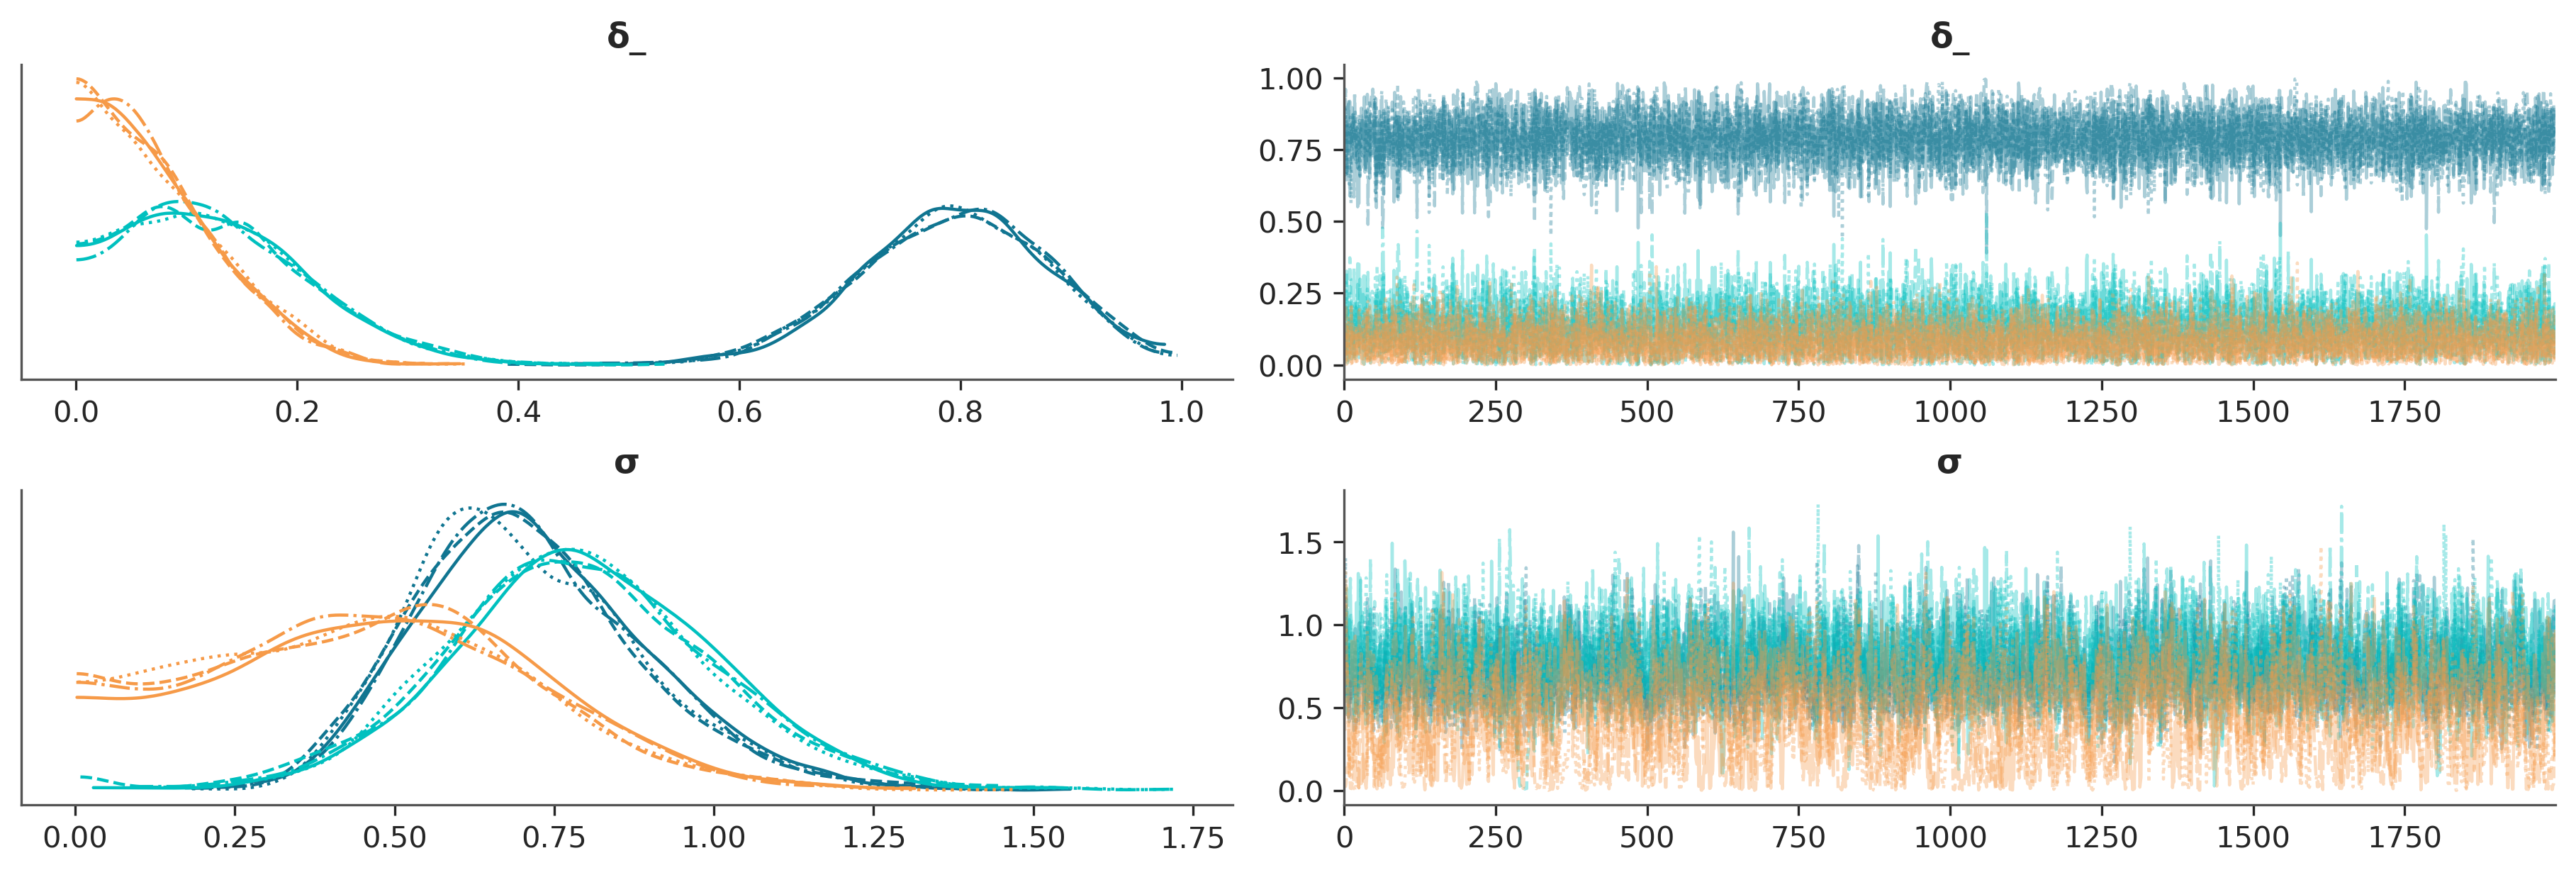

In [13]:
az.plot_trace(idata, var_names=["δ_", "σ"])
plt.show()

## Create a plot of probability of contraception by districts

In [14]:
# Dictionary of district and urban
unique_district_urban = (
    df
    .groupby("district")
    ["urban"]
    .max()
    .reset_index()
)
unique_district_urban.head()

,district,urban
0,1,1
1,2,0
2,3,1
3,4,1
4,5,1


In [15]:
#idata.posterior_predictive["likelihood"].sel(obs=[0, 1, 2, 3]).mean()

# Create a dataframe of districts and contraception use
post_p_dict = {
    "district": [],
    "lower_hdi": [],
    "upper_hdi": [],
    "mean": [],
    "urban": []
}
for d in df["district"].unique():

    obs_idx = df.loc[df["district"] == d].index

    lower_hdi, upper_hdi = az.hdi(idata.posterior["p"].sel(obs=obs_idx), input_core_dims=[["chain", "draw", "obs"]])["p"].values
    mean_val = idata.posterior["p"].sel(obs=obs_idx).mean().values

    post_p_dict["district"].append(d)
    post_p_dict["lower_hdi"].append(lower_hdi)
    post_p_dict["upper_hdi"].append(upper_hdi)
    post_p_dict["mean"].append(mean_val)
    post_p_dict["urban"].append(unique_district_urban.loc[unique_district_urban["district"]==d,"urban"].item())
    

In [16]:
post_p_df = pd.DataFrame(post_p_dict)

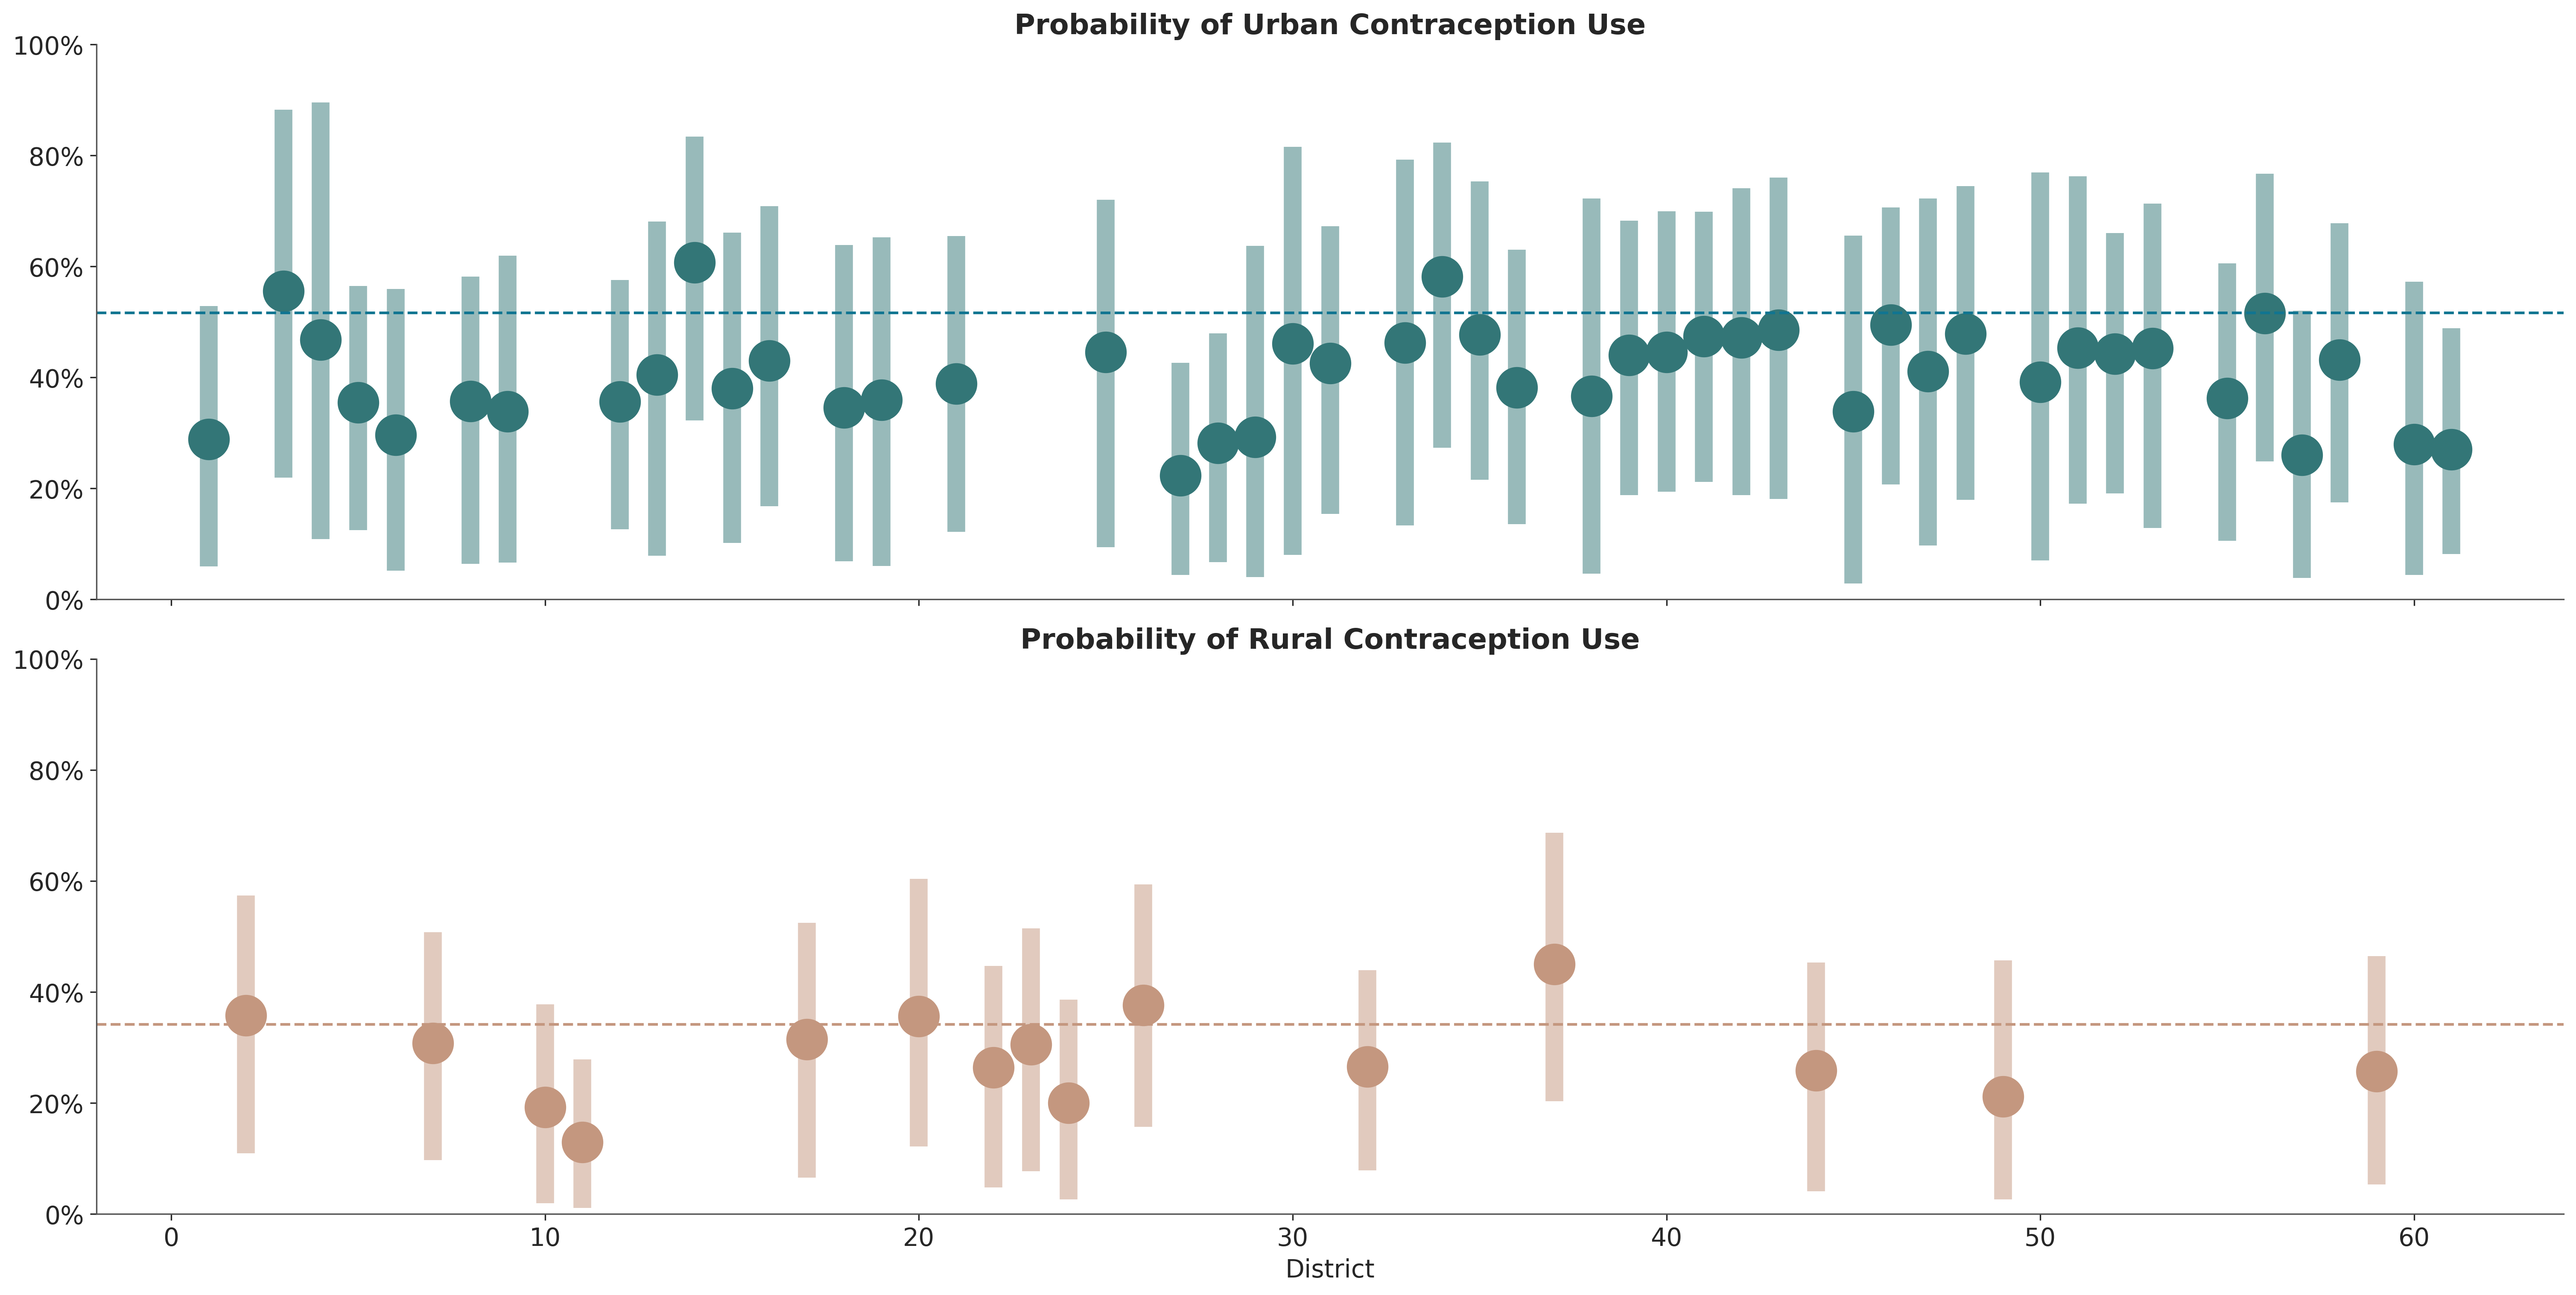

In [17]:
_, axes = plt.subplots(figsize=(20., 10.), nrows=2, ncols=1, sharex=True)

colors_list = ["#337677", "#C4977F"]
# Urban
u_df = post_p_df.loc[lambda q: q["urban"].eq(1)]
axes[0].vlines(u_df["district"].values, 
           ymin=u_df["lower_hdi"], 
           ymax=u_df["upper_hdi"], 
           lw=10,
           colors=colors_list[0],
           alpha=0.5
          )
axes[0].scatter(
    u_df["district"].values,
    u_df["mean"],
    c=colors_list[0],
    s=500
)
axes[0].axhline(df[df["urban"]==1]["use.contraception"].mean(), ls="--")

# Rural
r_df = post_p_df.loc[lambda q: q["urban"].eq(0)]
axes[1].vlines(r_df["district"].values, 
           ymin=r_df["lower_hdi"], 
           ymax=r_df["upper_hdi"], 
           lw=10,
           colors=colors_list[1],
           alpha=0.5
          )
axes[1].scatter(
    r_df["district"].values,
    r_df["mean"],
    c=colors_list[1],
    s=500
)
axes[1].axhline(df[df["urban"]==0]["use.contraception"].mean(), ls="--", c=colors_list[1])
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].set_title("Probability of Urban Contraception Use")
axes[1].set_title("Probability of Rural Contraception Use")
axes[0].set_ylim([0, 1]); axes[1].set_ylim([0, 1])
axes[1].set_xlabel("District")
plt.show()